# LOINC Crosswalk — Corpus & Simulation Visualization

This notebook drives all visualization functions from `corpus_and_simulation_viz.py`.

**Best configs:**
- TF-IDF: `lcn_method_dict_combined`, `tfidf_word`, ngram `(1,1)`
- ST: `pritamdeka/S-PubMedBert-MS-MARCO`, `regular_corpus`

**Sections:**
1. Setup & Data Loading
2. Simulation Quality: Noise Audit
3. Simulation Quality: Structural Composition
4. Token Frequency: Expanded Corpus vs ELR Queries
5. IDF Profiles Across Corpus Strategies
6. LOINC Corpus Geometry: UMAP (TF-IDF)
7. Joint UMAP: Corpus Documents + ELR Queries
8. LOINC Similarity Clustermap
9. Within- vs Between-Group Similarity (TF-IDF × ST)
10. Similarity Distribution Shapes: TF-IDF vs ST
11. ELR String Diagnostics

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import sys

notebook_dir = Path(os.getcwd())
repo_root = notebook_dir if (notebook_dir / 'src').exists() else notebook_dir.parent

sys.path.insert(0, str(repo_root))
os.chdir(repo_root)

from src.clinical_utils import clean_text
from src.model_building_utils import (
    expand_loinc_lcn,
    normalize_elr,
    compute_relatednames_stopwords,
)
from src.corpus_and_simulation_viz import (
    plot_simulation_noise_audit,
    plot_simulation_structure,
    plot_noise_by_coverage,
    plot_corpus_vs_elr_token_freq,
    plot_strategy_idf_profiles,
    plot_tfidf_corpus_umap,
    plot_tfidf_joint_umap,
    plot_loinc_similarity_clustermap,
    plot_within_between_similarity,
    plot_st_within_between_similarity,
    plot_similarity_distributions_from_names,
    plot_elr_length_distribution,
    plot_elr_token_collision_audit,
    _sim_pairs_tfidf,
    _sim_pairs_st,
    plot_similarity_distributions,
)

sns.set_theme(style="whitegrid", font_scale=1.0)
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

In [2]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
BEST_TFIDF_STRATEGY  = "lcn_method_dict_combined"
BEST_TFIDF_NGRAM     = (1, 1)
BEST_ST_MODEL        = "pritamdeka/S-PubMedBert-MS-MARCO"

# Strategies to compare in multi-strategy plots
STRATEGIES_TO_COMPARE = [
    "lcn_only",
    "lcn_method_dict_combined",
#    "lcn_method_dict_filtered_rn",
#    "component_weighted_method_dict",
]

# All ST models tested
ALL_ST_MODELS = [
    "sentence-transformers/all-MiniLM-L6-v2",
 #   "cambridgeltl/SapBERT-from-PubMedBERT-fulltext",
  #  "sentence-transformers/msmarco-distilbert-base-v4",
    "pritamdeka/S-PubMedBert-MS-MARCO",
   # "neuml/pubmedbert-base-embeddings",
   # "cambridgeltl/SapBERT-from-PubMedBERT-fulltext-mean-token",
]

In [3]:
# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------
elr = pd.read_csv("data/processed/elr_simulated.csv")
loinc = pd.read_csv("data/processed/covid_surveillance_loinc.csv")
loinc = loinc[~loinc["method_typ"].isna()].copy()

# Add retrieval-side expansions — never used in simulation
loinc["expanded_lcn"] = loinc["long_common_name"].map(clean_text).map(expand_loinc_lcn)
elr["elr_name_normalized"] = elr["elr_name"].map(clean_text).map(normalize_elr)

# RelatedNames2 stopwords for filtered strategies
rn_stopwords = compute_relatednames_stopwords(loinc, threshold=0.85)

# ELR val set only (consistent with ablation)
from src.ablation import load_data
elr_full, _, _, _ = load_data()
elr_val = elr_full[elr_full["split"] == "val"].copy()

print(f"LOINC:    {loinc.shape[0]} rows, {loinc['loinc_num'].nunique()} unique codes")
print(f"ELR full: {elr.shape[0]:,} rows")
print(f"ELR val:  {elr_val.shape[0]:,} rows")
print(f"RelatedNames2 stopwords: {len(rn_stopwords)} tokens")

LOINC:    98 rows, 98 unique codes
ELR full: 6,600 rows
ELR val:  5,280 rows
RelatedNames2 stopwords: 51 tokens


## 2. Simulation Quality: Noise Audit

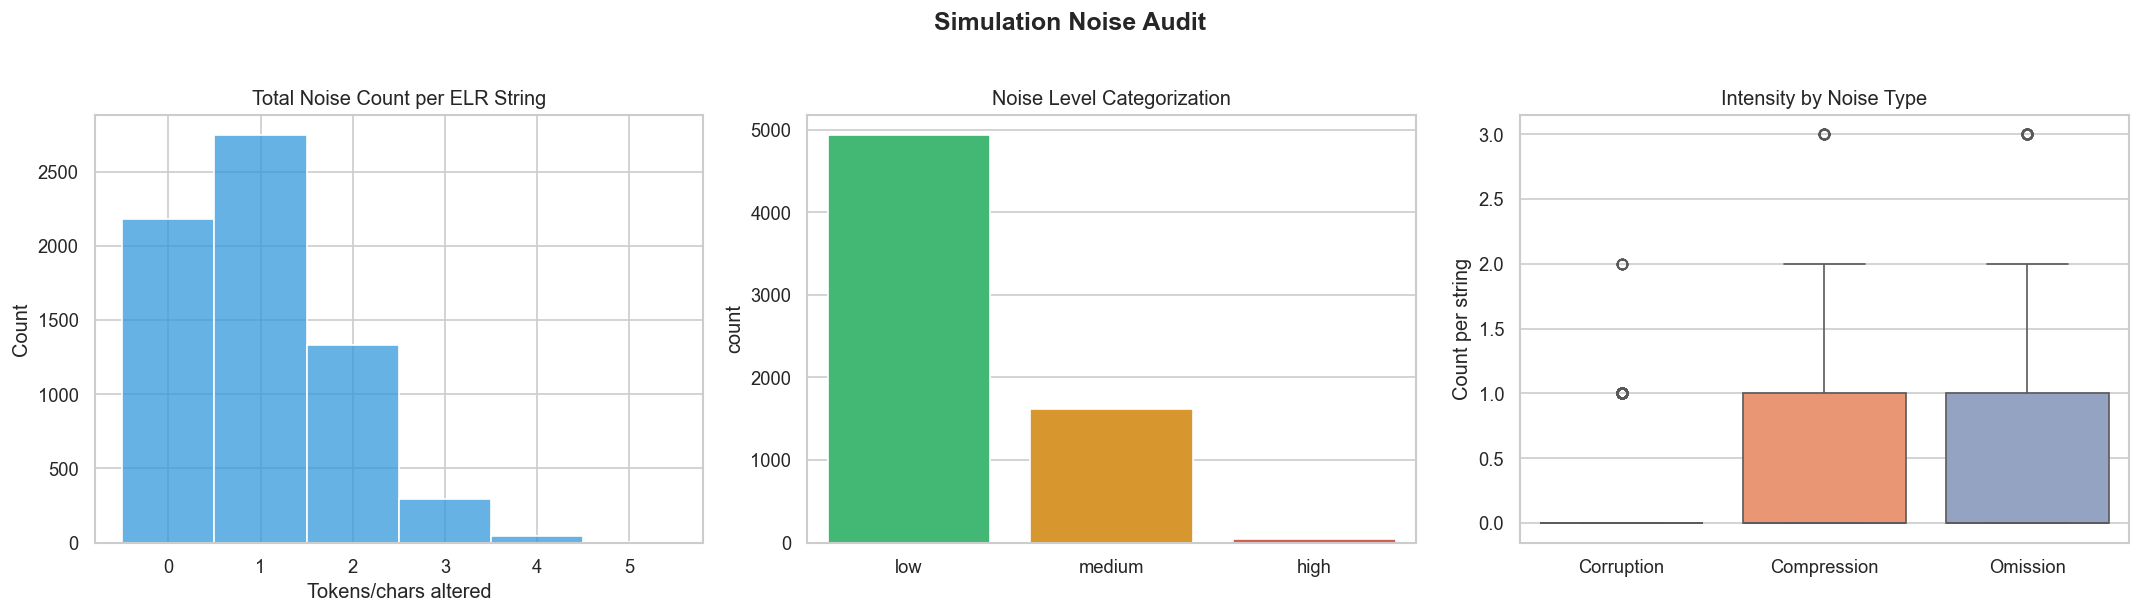

In [4]:
fig = plot_simulation_noise_audit(elr)
fig.savefig("data/results/viz_noise_audit.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Noise summary stats
noise_summary = elr[["noise_corruption", "noise_compression", "noise_omission", "noise_total"]].describe().T
print("Noise summary statistics:")
display(noise_summary.round(3))

Noise summary statistics:


,count,mean,std,min,25%,50%,75%,max
noise_corruption,6600.0,0.097,0.300,0.0,0.0,0.0,0.0,2.0
noise_compression,6600.0,0.566,0.632,0.0,0.0,0.0,1.0,3.0
noise_omission,6600.0,0.316,0.571,0.0,0.0,0.0,1.0,3.0
noise_total,6600.0,0.980,0.880,0.0,0.0,1.0,2.0,5.0


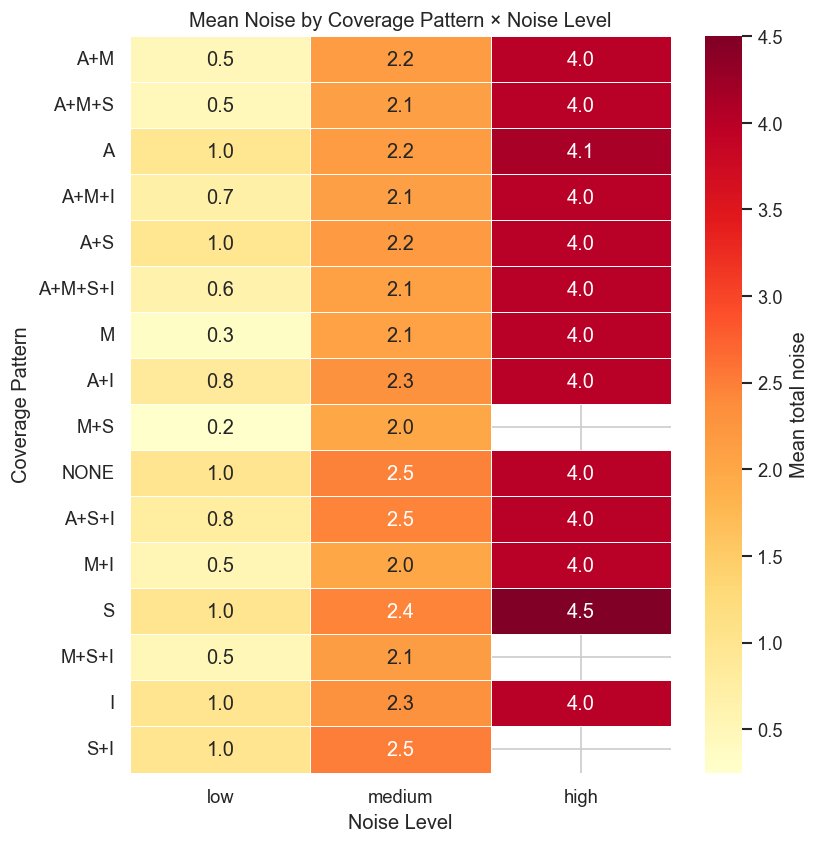

In [6]:
# Noise × coverage pattern heatmap
fig = plot_noise_by_coverage(elr)
fig.savefig("data/results/viz_noise_by_coverage.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Simulation Quality: Structural Composition

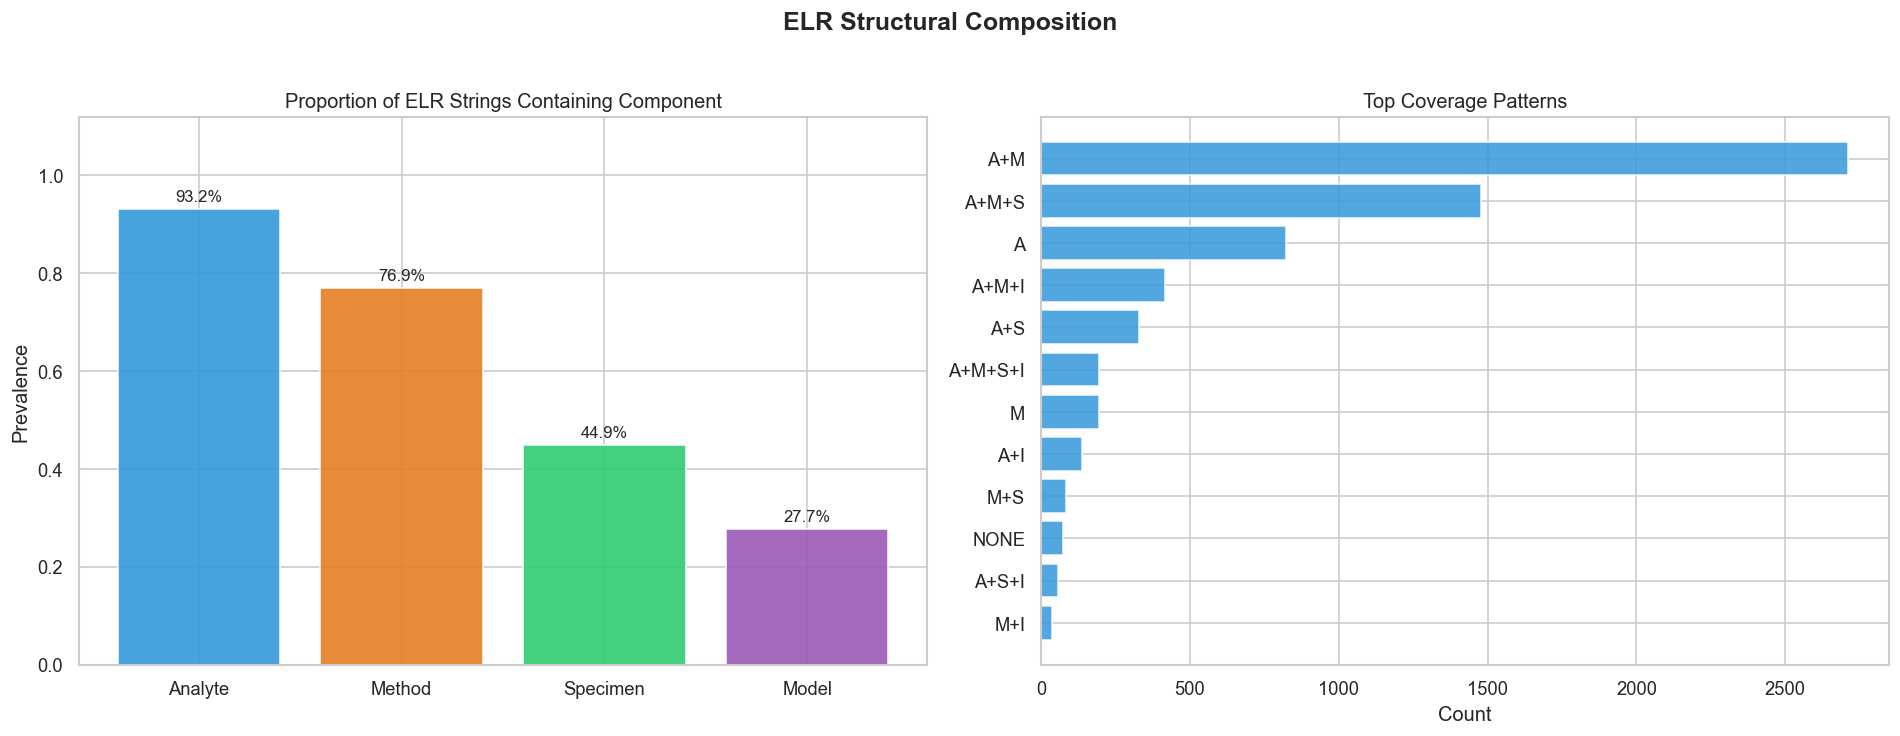

In [7]:
fig = plot_simulation_structure(elr)
fig.savefig("data/results/viz_structure.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Coverage pattern breakdown — full table
cov_counts = elr["coverage_pattern"].value_counts().reset_index()
cov_counts.columns = ["coverage_pattern", "count"]
cov_counts["pct"] = (cov_counts["count"] / len(elr) * 100).round(1)
display(cov_counts)

,coverage_pattern,count,pct
0,A+M,2712,41.1
1,A+M+S,1477,22.4
2,A,824,12.5
3,A+M+I,416,6.3
4,A+S,329,5.0
5,A+M+S+I,196,3.0
6,M,193,2.9
7,A+I,137,2.1
8,M+S,84,1.3
9,NONE,75,1.1


In [9]:
# LOINC class distribution
print("LOINC code distribution (unique codes by method_typ):")
display(loinc.groupby("method_typ")["loinc_num"].nunique().sort_values(ascending=False))

LOINC code distribution (unique codes by method_typ):


method_typ
Probe.amp.tar                            59
Non-probe.amp.tar                        28
IA.rapid                                  7
Probe.amp.tar.CDC primer-probe set N1     2
IA                                        1
Probe.amp.tar.CDC primer-probe set N2     1
Name: loinc_num, dtype: int64

## 4. Token Frequency: Expanded Corpus vs ELR Queries

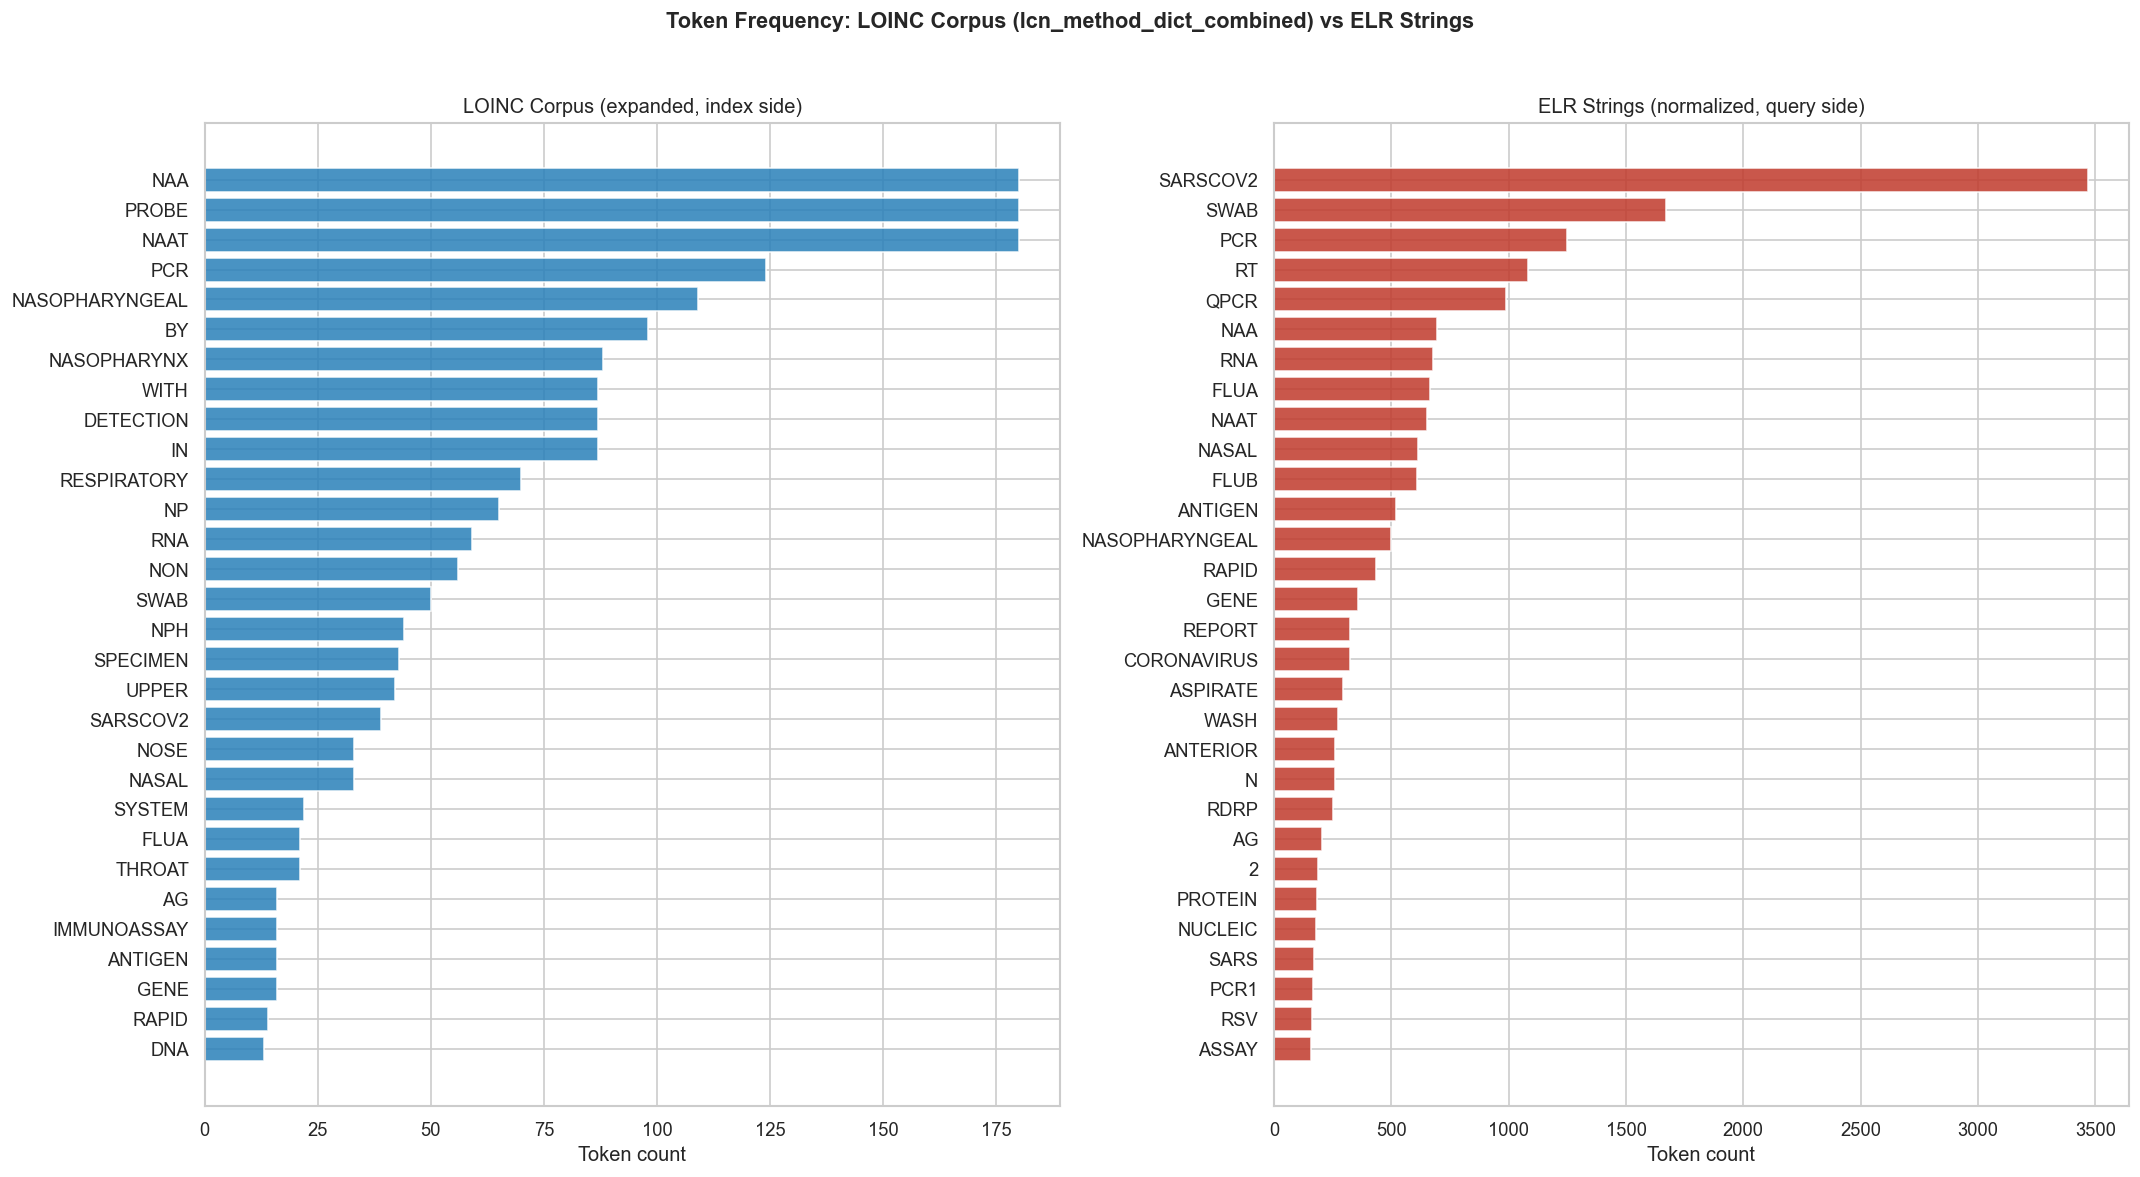

In [10]:
fig = plot_corpus_vs_elr_token_freq(
    loinc,
    elr_val,
    corpus_strategy=BEST_TFIDF_STRATEGY,
    rn_stopwords=rn_stopwords,
    top_n=30,
)
fig.savefig("data/results/viz_token_freq.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Vocabulary size comparison
from collections import Counter

from src.model_building_utils import build_corpus
corpus_tokens = " ".join(build_corpus(loinc, BEST_TFIDF_STRATEGY, rn_stopwords).fillna("")).split()
elr_tokens = " ".join(elr_val["elr_name_normalized"].fillna("")).split()
corpus_vocab = set(corpus_tokens)
elr_vocab = set(elr_tokens)

print(f"Corpus vocabulary size:   {len(corpus_vocab):,}")
print(f"ELR vocabulary size:      {len(elr_vocab):,}")
print(f"ELR tokens not in corpus: {len(elr_vocab - corpus_vocab):,}")
print(f"Coverage rate:            {len(elr_vocab & corpus_vocab) / len(elr_vocab):.1%}")

# Top uncovered tokens (typos + genuine gaps)
uncovered = sorted(elr_vocab - corpus_vocab)
print(f"\nSample uncovered tokens: {uncovered[:20]}")

Corpus vocabulary size:   135
ELR vocabulary size:      619
ELR tokens not in corpus: 571
Coverage rate:            7.8%

Sample uncovered tokens: ['0', '119', '19', '1COPY', '1H', '2009PDM', '200P9DM', '2RNA', '3EO', '5SWAB', '6800', '6PCR', '8', '8PCR1', '9', 'A6CIDS', 'AA', 'AAG', 'AASPIRATE', 'AAT']


## 5. IDF Profiles Across Corpus Strategies

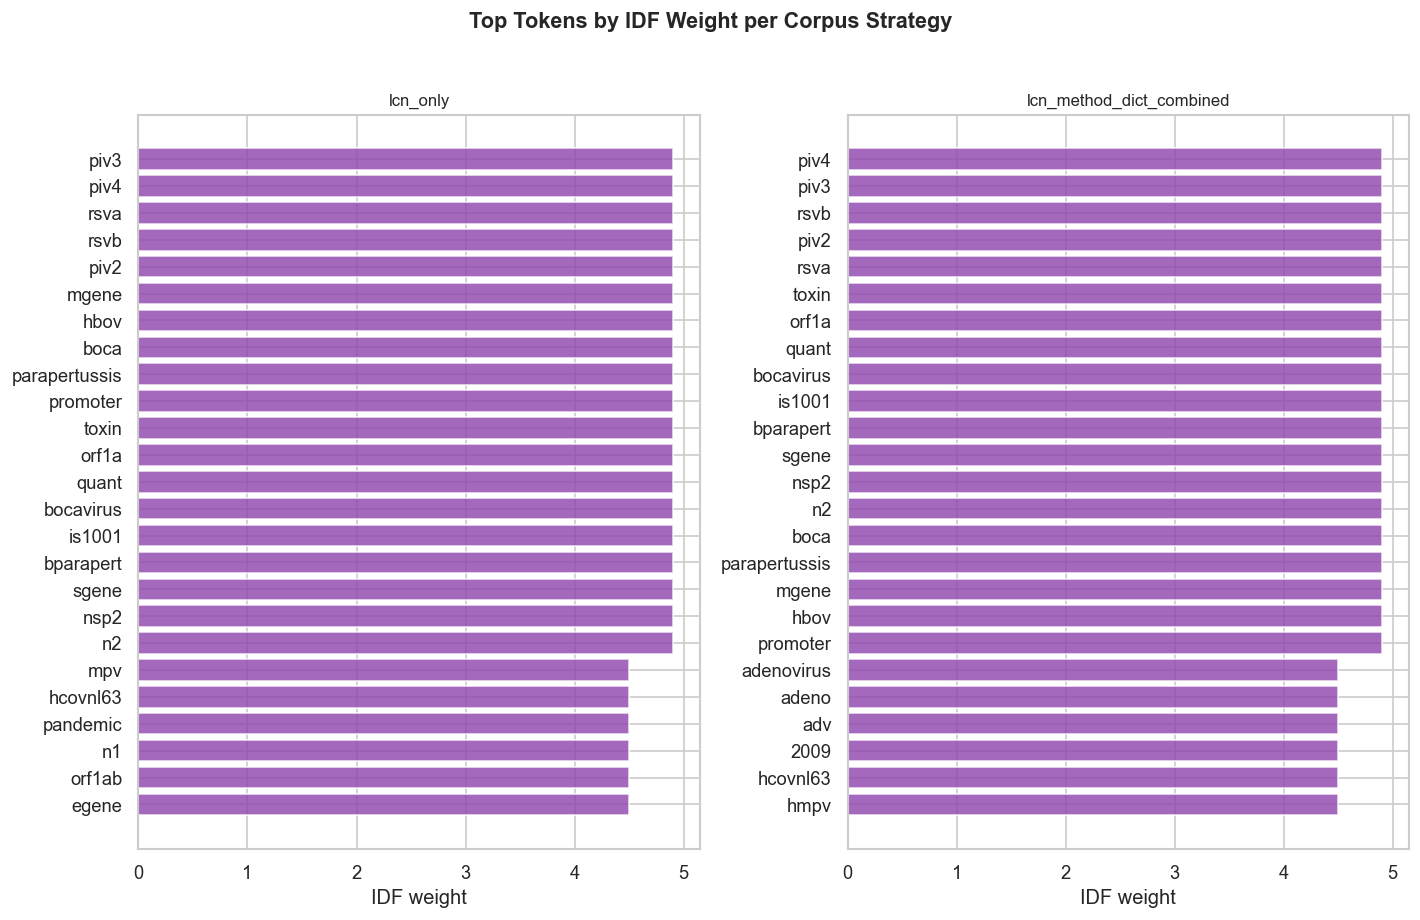

In [12]:
fig = plot_strategy_idf_profiles(
    loinc,
    STRATEGIES_TO_COMPARE,
    rn_stopwords=rn_stopwords,
    top_n=25,
)
fig.savefig("data/results/viz_idf_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. LOINC Corpus Geometry: UMAP (TF-IDF)

UMAP with `metric='cosine'` is used instead of MDS. MDS on cosine-distance matrices of high-dimensional TF-IDF vectors produces the horseshoe artifact because the distance matrix violates Euclidean assumptions. UMAP operates in the original metric space directly.

Note that both methods separate antigen vs naat tests well but lcn_only does not distinguish specimen eg. nose vs nasopharynx quite as cleanly.

c:\Users\prach\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\prach\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


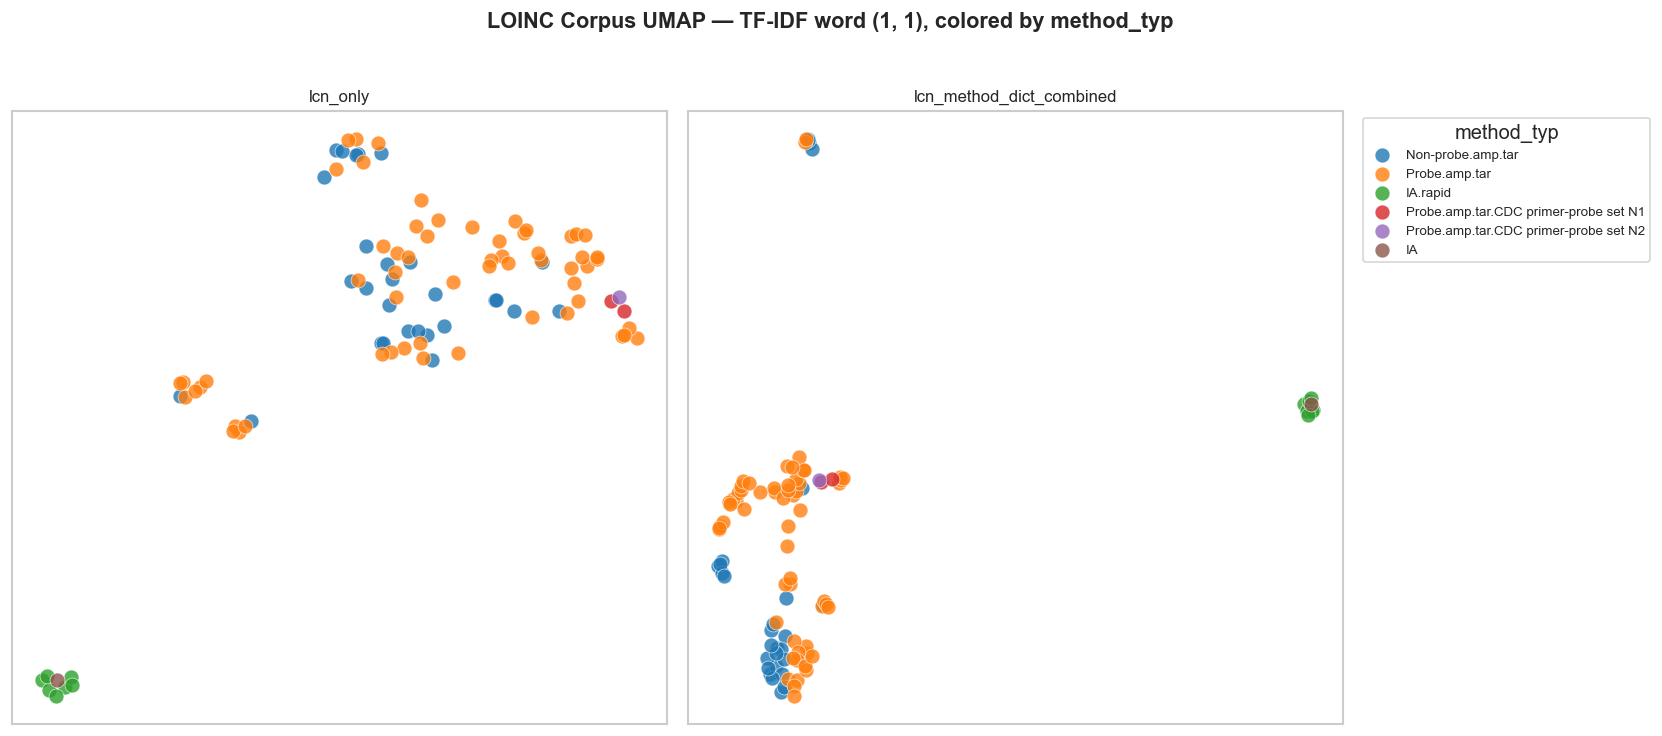

In [13]:
# Colored by method_typ — shows whether the corpus cleanly separates NAAT from antigen
fig = plot_tfidf_corpus_umap(
    loinc,
    STRATEGIES_TO_COMPARE,
    rn_stopwords=rn_stopwords,
    ngram_range=BEST_TFIDF_NGRAM,
    color_by="method_typ",
    n_neighbors=12,
)
fig.savefig("data/results/viz_corpus_umap_method.png", dpi=150, bbox_inches="tight")
plt.show()

c:\Users\prach\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


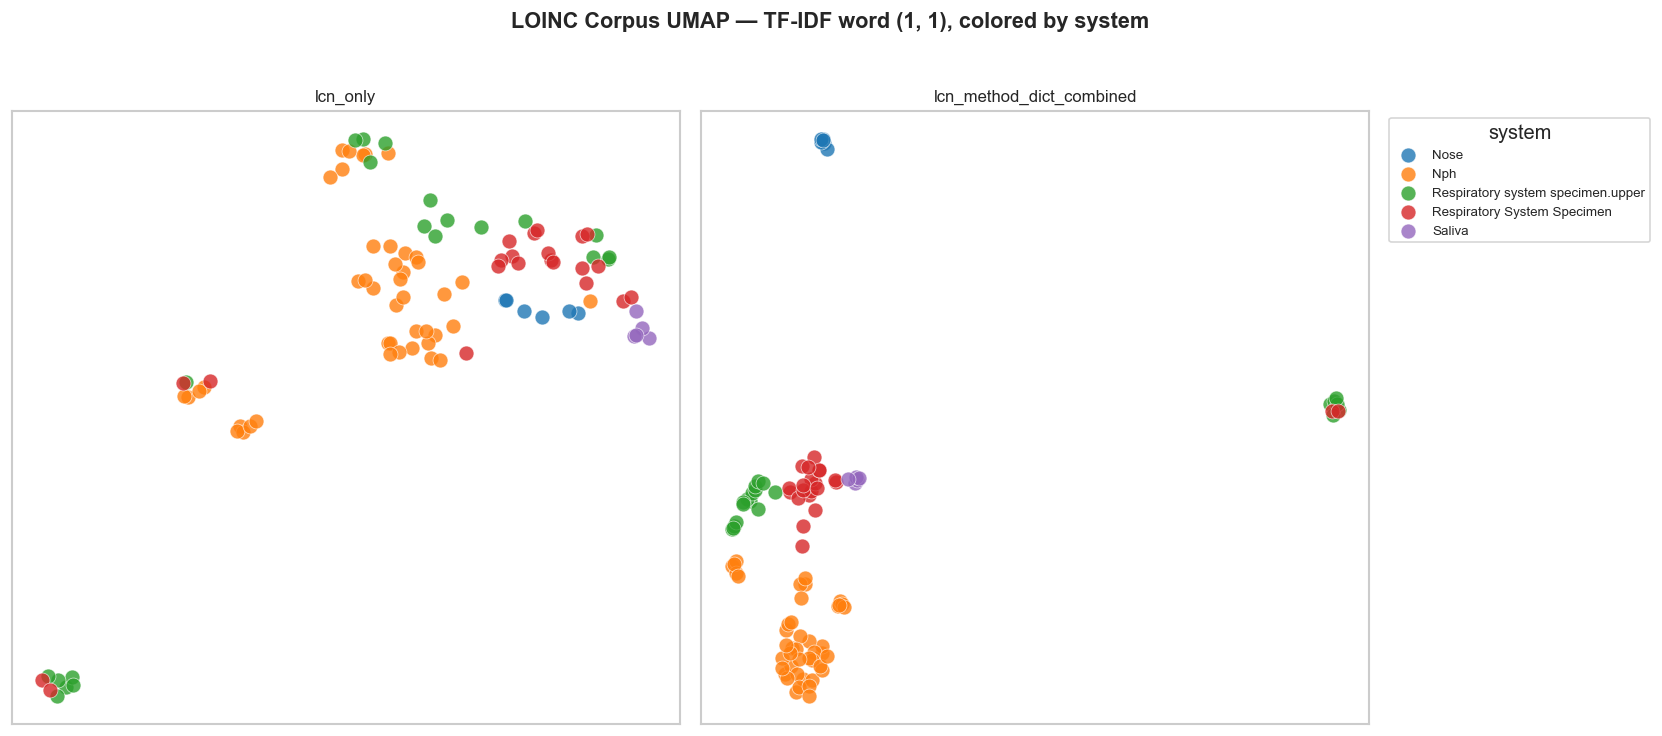

In [14]:
# Colored by system — shows specimen axis separation
fig = plot_tfidf_corpus_umap(
    loinc,
    STRATEGIES_TO_COMPARE,
    rn_stopwords=rn_stopwords,
    ngram_range=BEST_TFIDF_NGRAM,
    color_by="system",
    n_neighbors=12,
)
fig.savefig("data/results/viz_corpus_umap_system.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Joint UMAP: Corpus Documents + ELR Queries

Fit on LOINC corpus, transform ELR queries into the same space. Good retrieval → ELR query points (small circles) cluster around the matching LOINC corpus point (star).

Note that while the TF-IDF queries cluster around the corresponding LOINCS, in the case of Sentence Transformer, the queries and LOINC groups form distinct clusters for the most part.

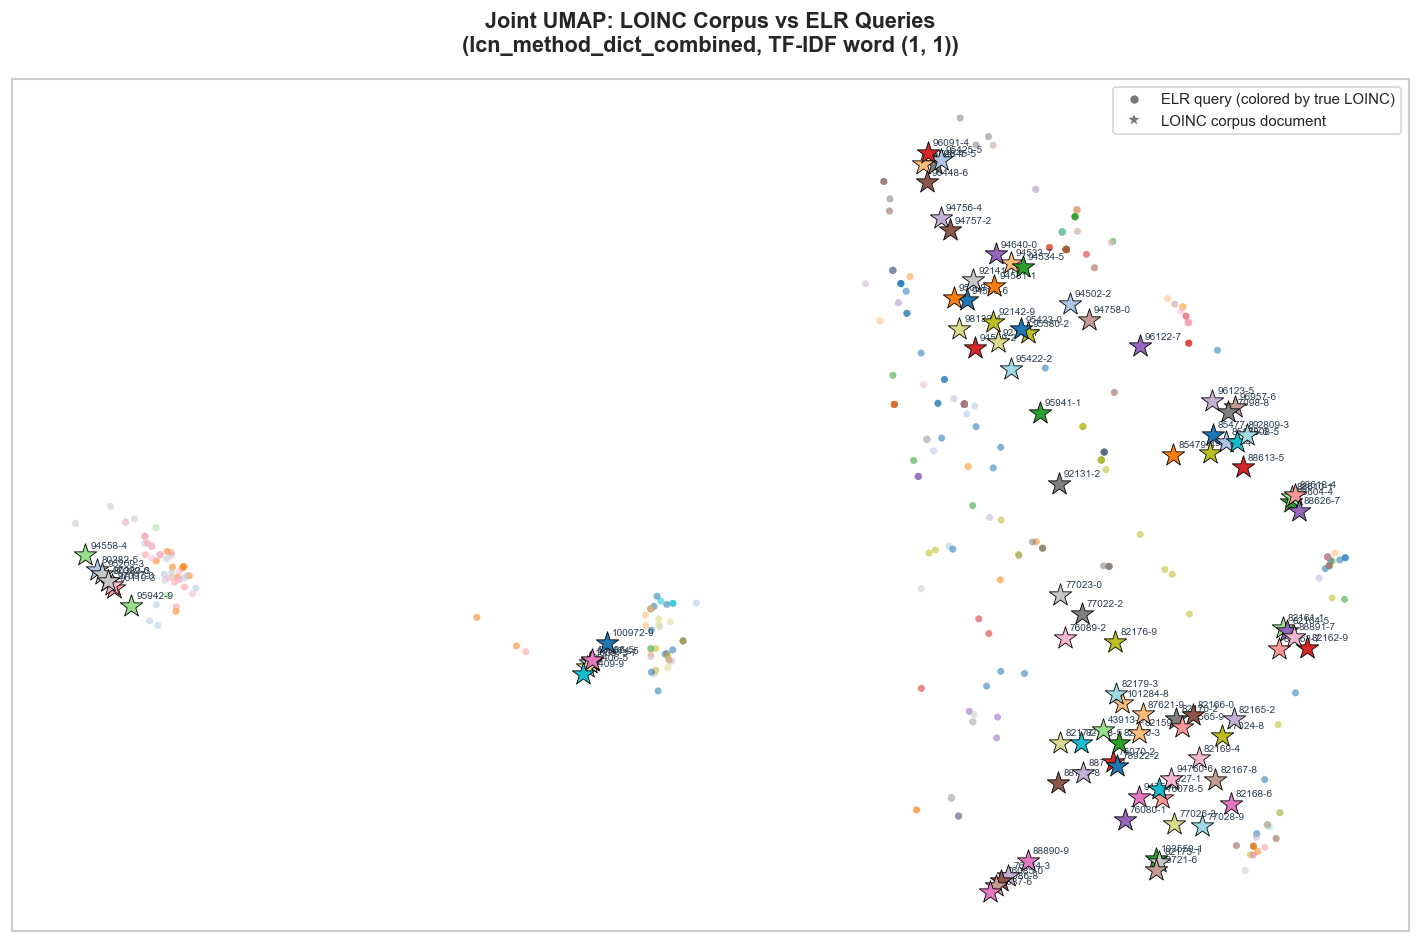

In [15]:
fig = plot_tfidf_joint_umap(
    loinc,
    elr_val,
    corpus_strategy=BEST_TFIDF_STRATEGY,
    rn_stopwords=rn_stopwords,
    ngram_range=BEST_TFIDF_NGRAM,
    n_neighbors=15,
    elr_sample=400,
)
fig.savefig("data/results/viz_joint_umap_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

15:00:06 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
15:00:06 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/pritamdeka/S-PubMedBert-MS-MARCO/96786c7024f95c5aac7f2b9a18086c7b97b23036/modules.json "HTTP/1.1 200 OK"
15:00:06 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
15:00:06 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
15:00:06 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/pritamdeka/S-PubMedBert-MS-MARCO/96786c7024f95c5aac7f2b9a18086c7b97b23036/config_sentence_transformers.json "HTTP/1.1 200 OK"
15:00:06 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/config_

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: pritamdeka/S-PubMedBert-MS-MARCO
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
15:00:08 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/refs%2Fpr%2F10/model.safetensors "HTTP/1.1 302 Found"
15:00:08 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
15:00:08 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
15:00:09 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
15:00:09 - INFO - HTTP Request: HEAD https://huggingface.co/pri

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

c:\Users\prach\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\prach\Desktop\LOINC codes crosswalk project\src\corpus_and_simulation_viz.py:724: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\prach\AppData\Local\Temp\ipykernel_20456\1201844369.py:10: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig_st_umap.savefig("data/results/viz_joint_umap_st.png", dpi=150, bbox_inches="tight")
c:\Users\prach\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


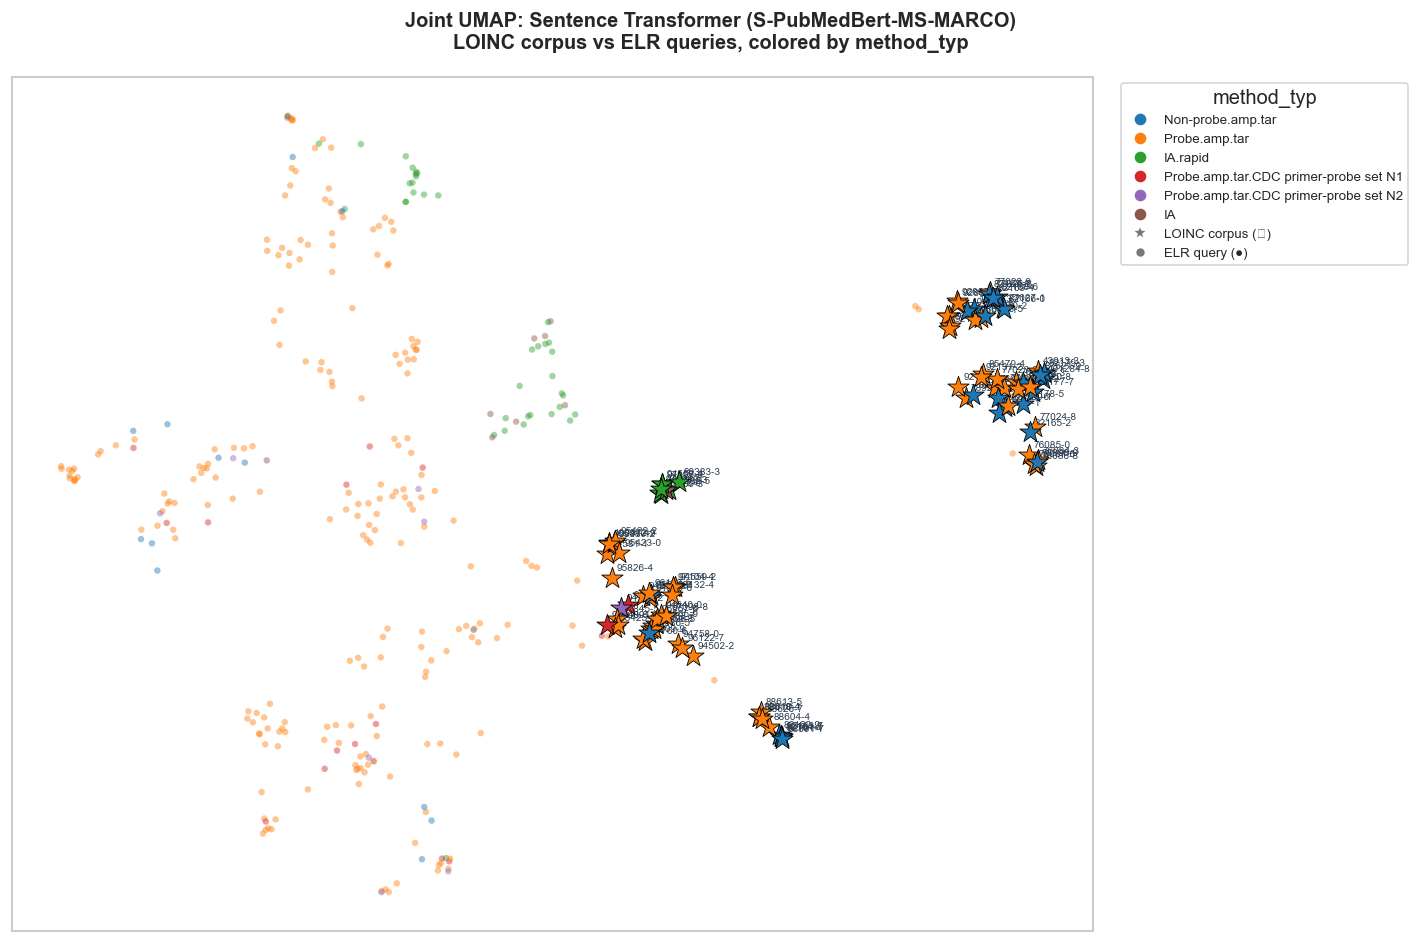

In [16]:
from src.corpus_and_simulation_viz import plot_st_corpus_umap
fig_st_umap = plot_st_corpus_umap(
    loinc,
    elr_val,
    model_name=BEST_ST_MODEL,
    color_by="method_typ",
    n_neighbors=12,
    elr_sample=300,
)
fig_st_umap.savefig("data/results/viz_joint_umap_st.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. LOINC Similarity Clustermap

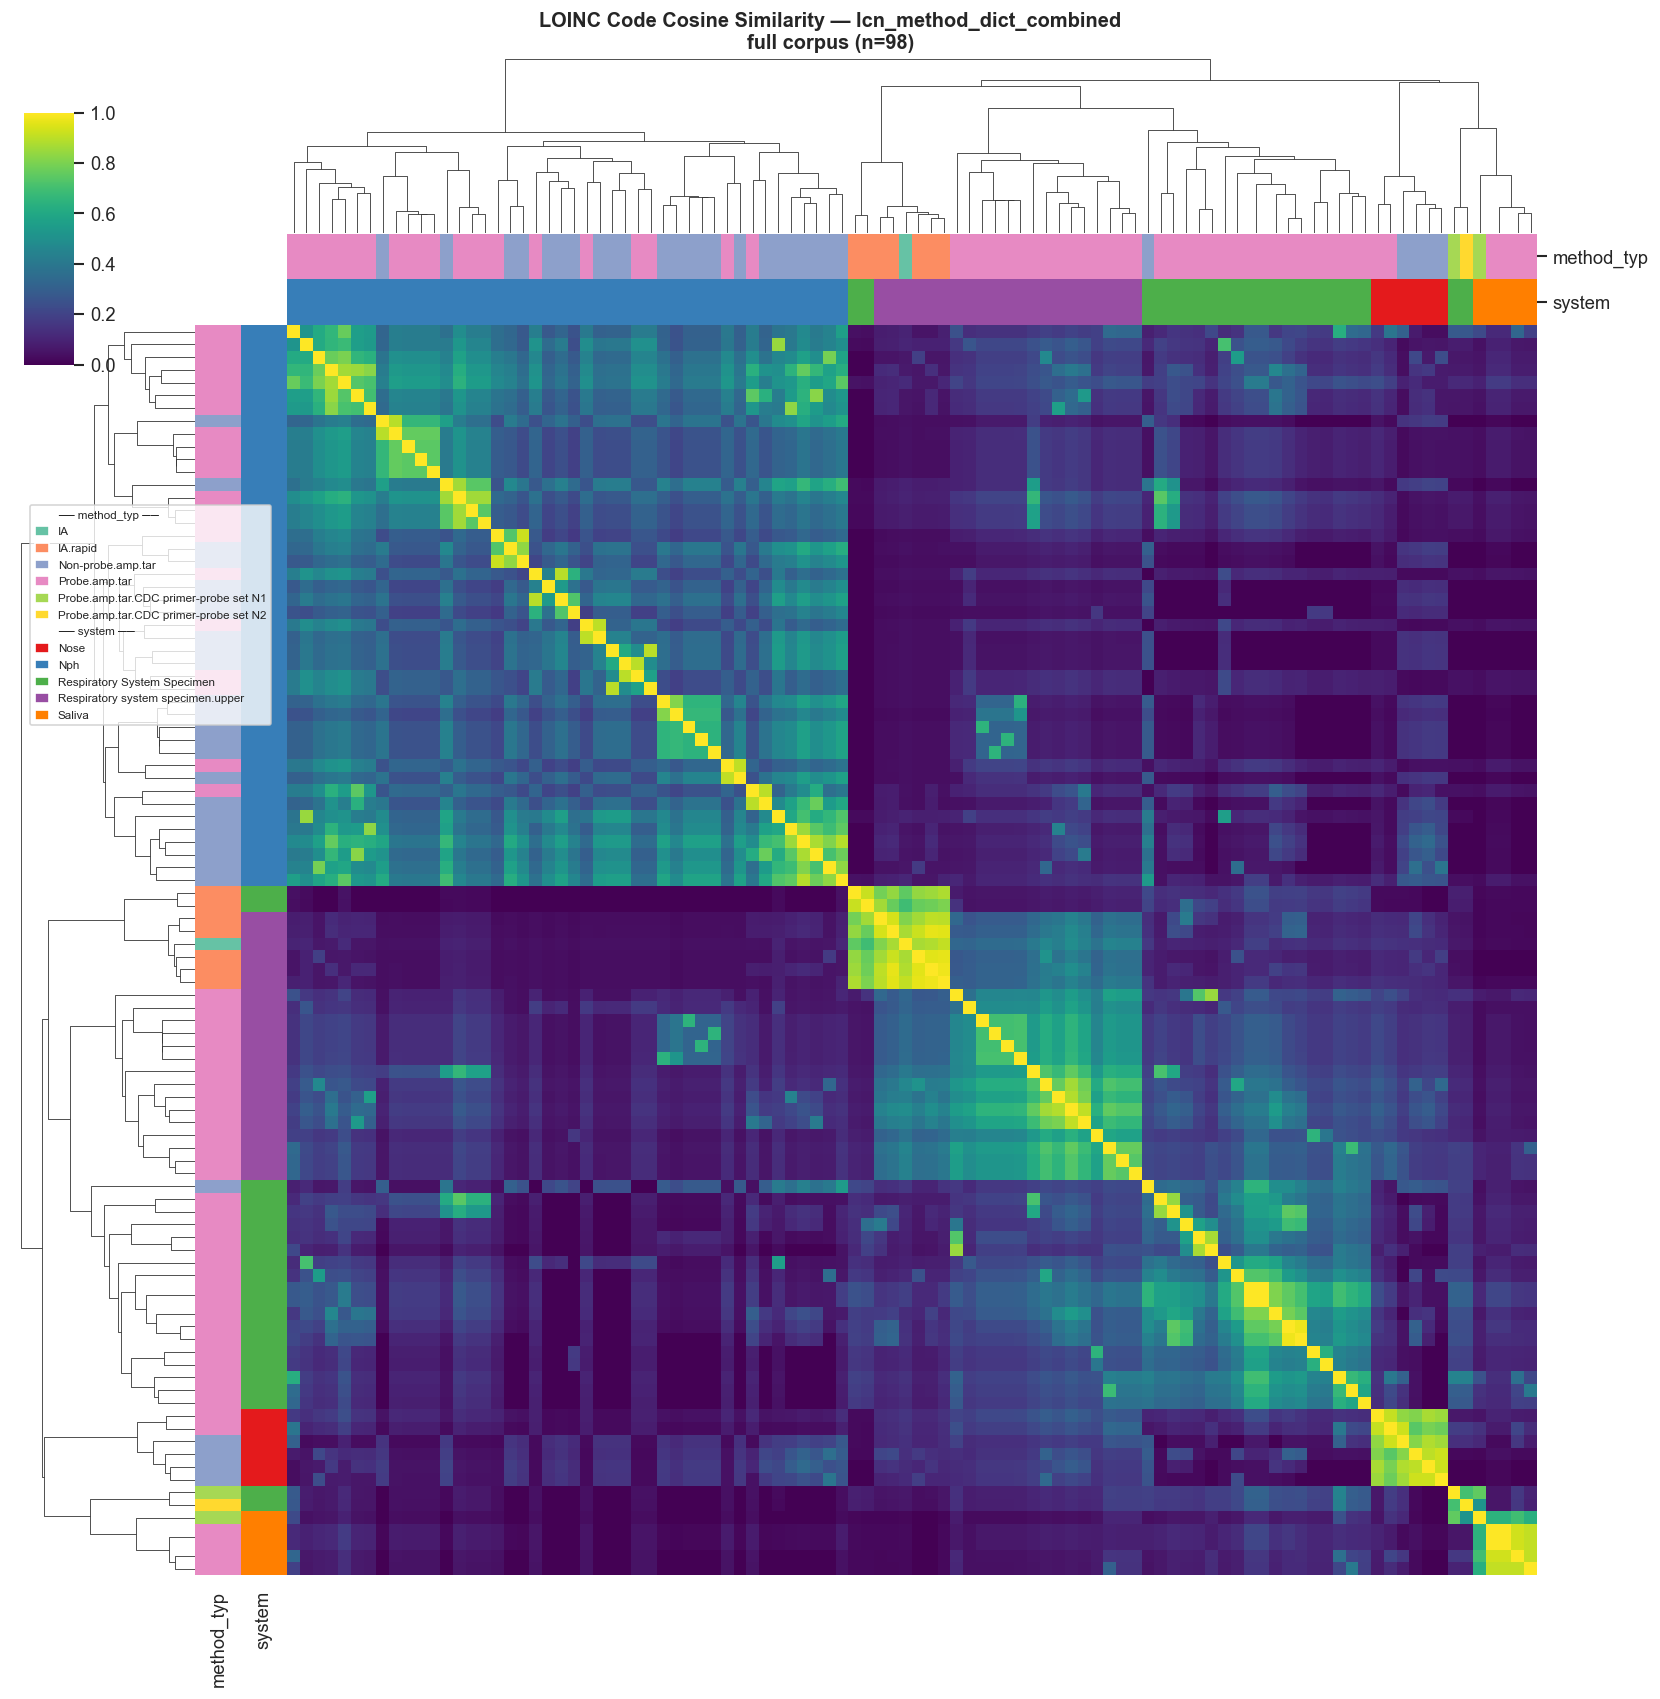

In [17]:
# Full-corpus clustermap (all unique LOINC codes, no labels — structure from sidebars)
cg_full = plot_loinc_similarity_clustermap(
    loinc,
    corpus_strategy=BEST_TFIDF_STRATEGY,
    rn_stopwords=rn_stopwords,
    ngram_range=BEST_TFIDF_NGRAM,
    eval_loincs=None,
)
cg_full.figure.savefig("data/results/viz_similarity_clustermap_full.png", dpi=150, bbox_inches="tight")
plt.show()

Eval LOINC codes (36): ['94500-6', '94845-5', '95406-5', '85477-8', '85478-6', '85479-4', '94558-4', '94534-5', '96123-5', '97097-0', '94756-4', '80382-5', '80383-3', '94533-7', '95409-9', '95608-6', '94759-8', '76078-5', '77028-9', '76080-1', '94640-0', '92142-9', '94757-2', '92141-1', '94559-2', '94565-9', '82166-0', '94502-2', '95209-3', '96119-3', '95423-0', '92131-2', '94760-6', '77024-8', '96448-6', '94758-0']


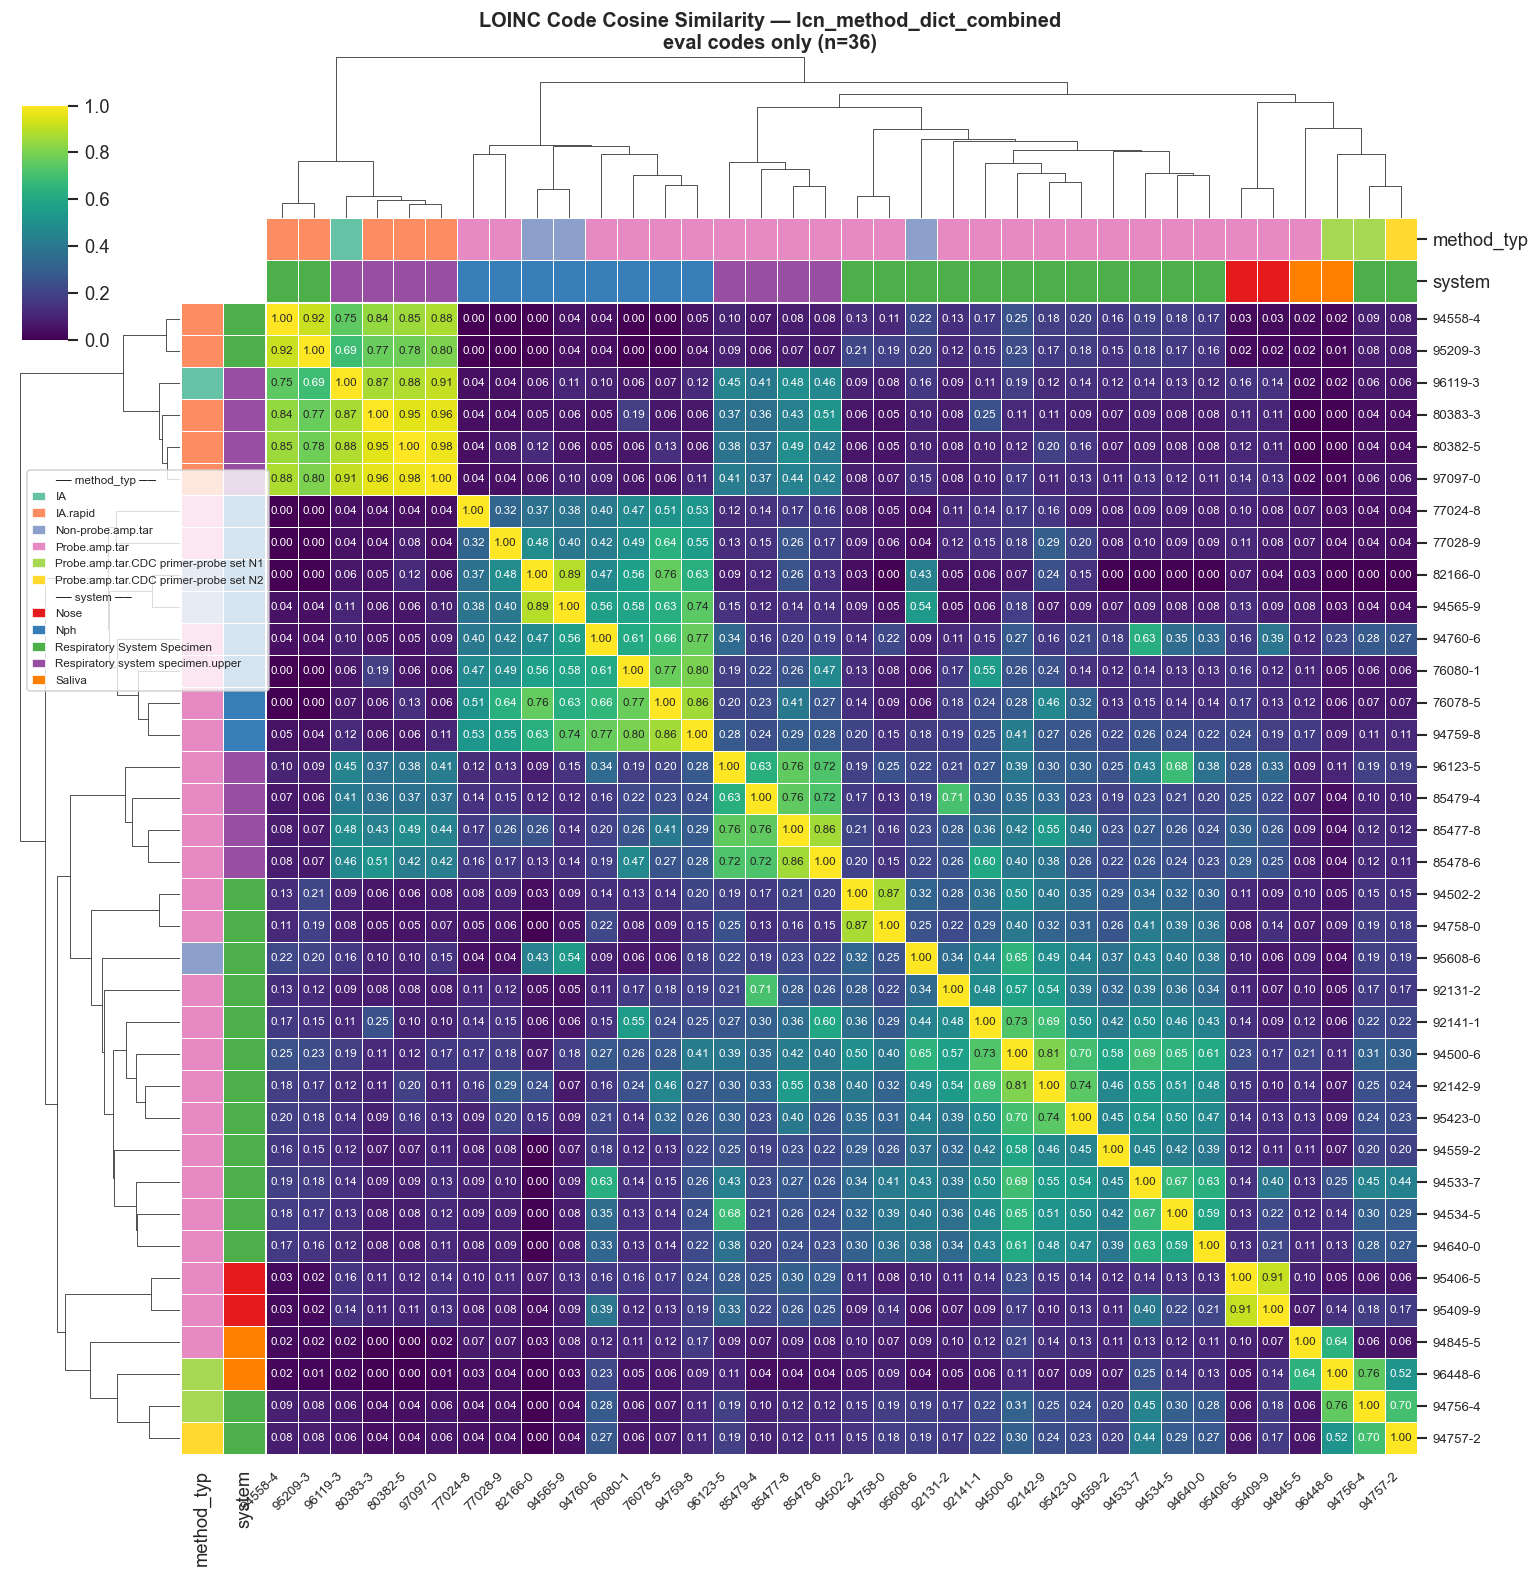

In [18]:
# Eval-codes-only clustermap (labeled + annotated — the portfolio-facing version)
eval_loincs = list(elr["loinc_num"].unique())
print(f"Eval LOINC codes ({len(eval_loincs)}): {eval_loincs}")

cg_eval = plot_loinc_similarity_clustermap(
    loinc,
    corpus_strategy=BEST_TFIDF_STRATEGY,
    rn_stopwords=rn_stopwords,
    ngram_range=BEST_TFIDF_NGRAM,
    eval_loincs=eval_loincs,
)
cg_eval.figure.savefig("data/results/viz_similarity_clustermap_eval.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Within- vs Between-Group Similarity

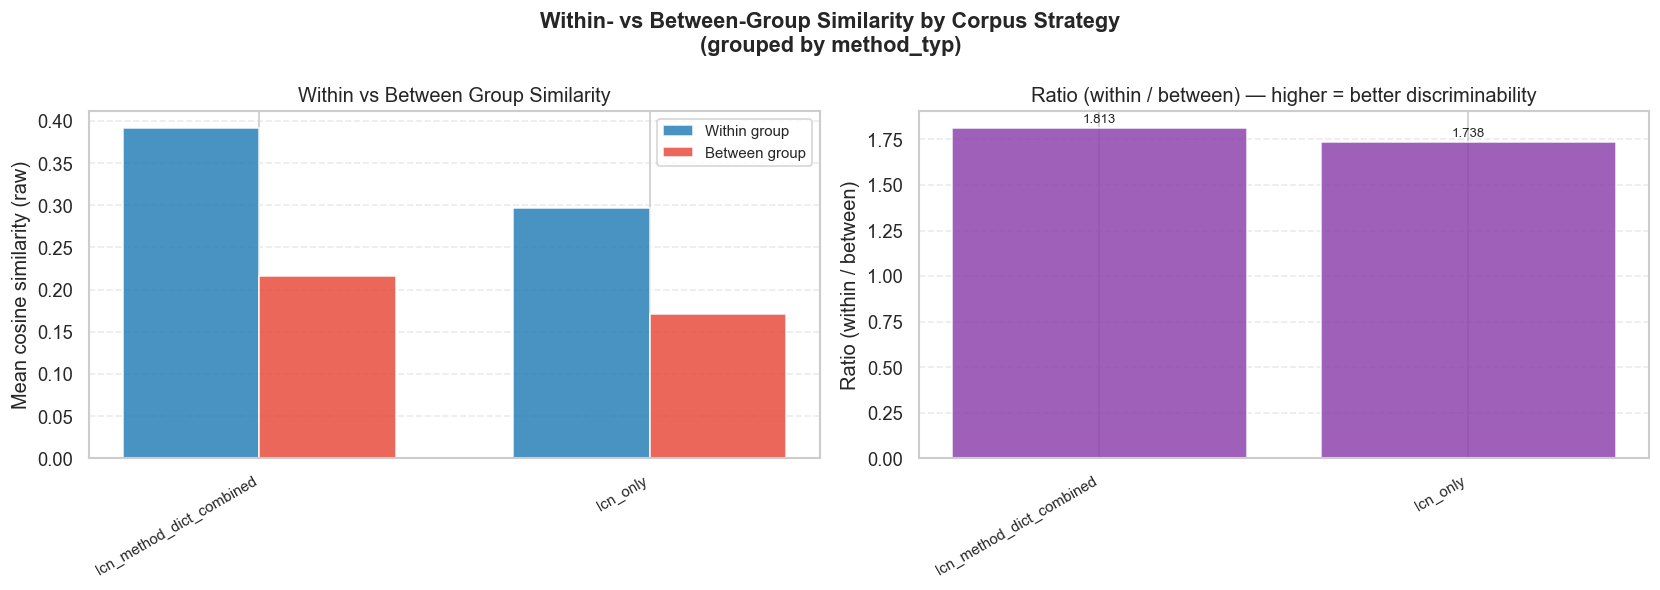

In [19]:
# TF-IDF: raw ratio (within / between) — strategy comparison
fig = plot_within_between_similarity(
    loinc,
    STRATEGIES_TO_COMPARE,
    rn_stopwords=rn_stopwords,
    ngram_range=BEST_TFIDF_NGRAM,
    group_by="method_typ",
    effect_size=False,
)
fig.savefig("data/results/viz_within_between_sim.png", dpi=150, bbox_inches="tight")
plt.show()

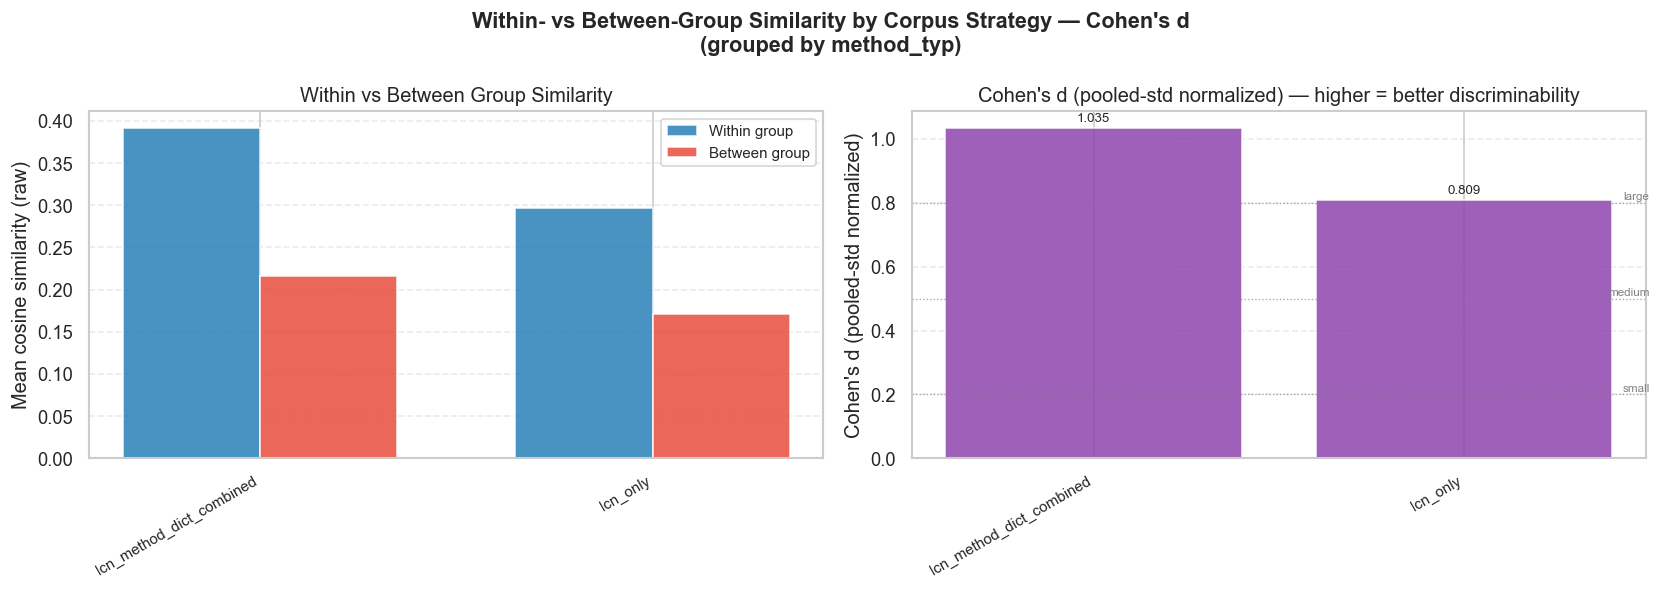

In [20]:
# TF-IDF: Cohen's d — cross-method comparable separation metric
# d = (mean_within - mean_between) / pooled_std
fig = plot_within_between_similarity(
    loinc,
    STRATEGIES_TO_COMPARE,
    rn_stopwords=rn_stopwords,
    ngram_range=BEST_TFIDF_NGRAM,
    group_by="method_typ",
    effect_size=True,
)
fig.savefig("data/results/viz_within_between_cohens_d.png", dpi=150, bbox_inches="tight")
plt.show()

15:00:58 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
15:00:58 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json "HTTP/1.1 200 OK"
15:00:58 - INFO - HTTP Request: GET https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json "HTTP/1.1 200 OK"


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\prach\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\prach\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
15:00:59 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resol

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

15:00:59 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
15:00:59 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/config_sentence_transformers.json "HTTP/1.1 200 OK"
15:00:59 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
15:00:59 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/README.md "HTTP/1.1 200 OK"
15:00:59 - INFO - HTTP Request: GET https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/README.md "HTTP/1.1 200 OK"


...

15:01:05 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
15:01:06 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/1_Pooling/config.json "HTTP/1.1 307 Temporary Redirect"
15:01:06 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/1_Pooling%2Fconfig.json "HTTP/1.1 200 OK"
15:01:06 - INFO - HTTP Request: GET https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/1_Pooling%2Fconfig.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

15:01:06 - INFO - HTTP Request: GET https://huggingface.co/api/models/sentence-transformers/all-MiniLM-L6-v2 "HTTP/1.1 200 OK"
15:01:07 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
15:01:07 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/pritamdeka/S-PubMedBert-MS-MARCO/96786c7024f95c5aac7f2b9a18086c7b97b23036/modules.json "HTTP/1.1 200 OK"
15:01:07 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
15:01:07 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/pritamdeka/S-PubMedBert-MS-MARCO/96786c7024f95c5aac7f2b9a18086c7b97b23036/config_sentence_transformers.json "HTTP/1.1 200 OK"
15:01:08 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/config_sentence_transformers.json "HTTP

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

15:01:09 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/refs%2Fpr%2F10/model.safetensors "HTTP/1.1 302 Found"
BertModel LOAD REPORT from: pritamdeka/S-PubMedBert-MS-MARCO
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
15:01:09 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
15:01:09 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
15:01:09 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
15:01:10 - INFO - HTTP Request: HEAD https://huggingface.co/pri

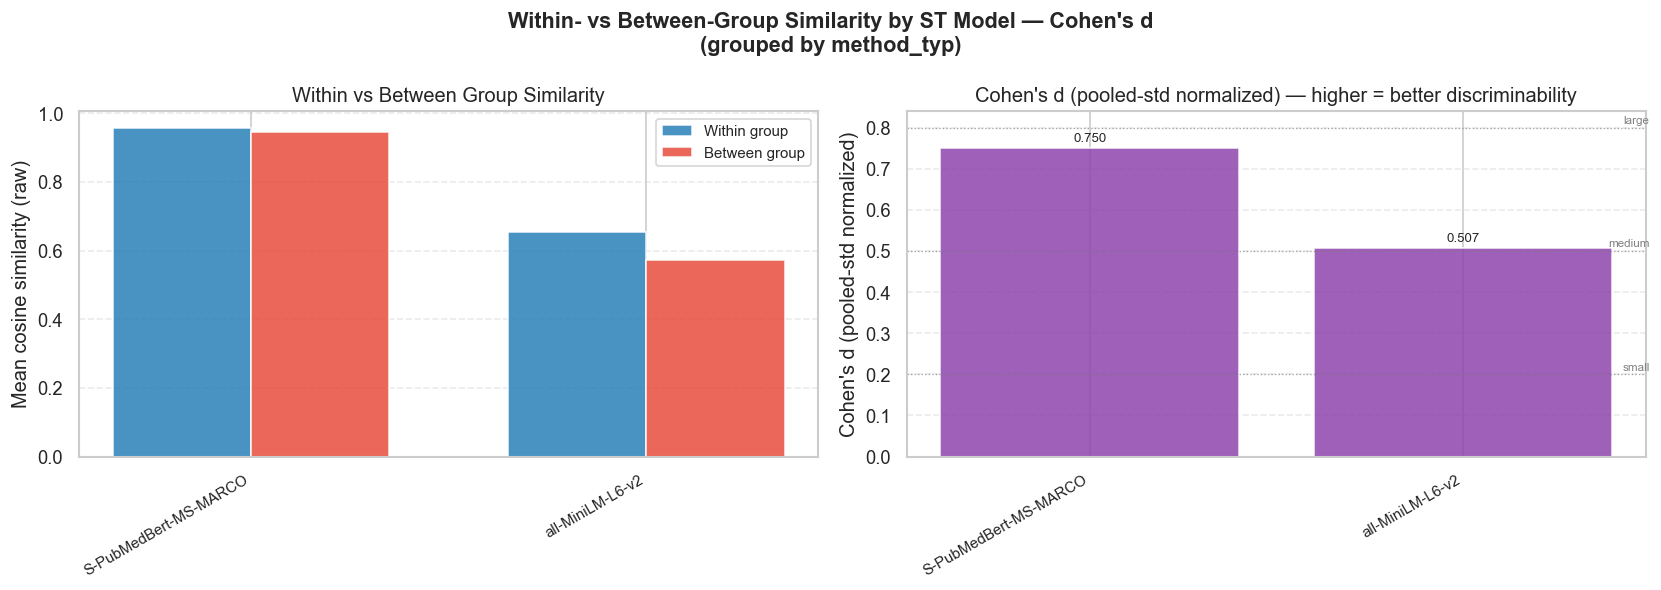

In [21]:
#ST models: Cohen's d across all tested models
fig_st_wb = plot_st_within_between_similarity(
    loinc,
    ALL_ST_MODELS,
    group_by="method_typ",
    effect_size=True,
)
fig_st_wb.savefig("data/results/viz_st_within_between_cohens_d.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Similarity Distribution Shapes: TF-IDF vs ST

KDE plots of pairwise cosine similarity distributions showing within-group vs between-group separation for the best TF-IDF config vs the best ST model. The raw x-axis is preserved so compression (rightward shift of both ST distributions relative to TF-IDF) is visible. Cohen's d is annotated on each panel.

**Note:** TF-IDF and ST ratios are NOT directly comparable as a separation metric due to scale differences in sparse vs dense embedding geometry. Cohen's d is the correct cross-method metric.

In [22]:
# Pre-compute similarity pairs for TF-IDF (fast)
tfidf_pairs = _sim_pairs_tfidf(
    loinc,
    BEST_TFIDF_STRATEGY,
    rn_stopwords,
    group_by="method_typ",
    ngram_range=BEST_TFIDF_NGRAM,
)
print(f"TF-IDF pairs — within: {len(tfidf_pairs['within'])}, between: {len(tfidf_pairs['between'])}")

TF-IDF pairs — within: 2111, between: 2642


15:01:18 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
15:01:18 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/pritamdeka/S-PubMedBert-MS-MARCO/96786c7024f95c5aac7f2b9a18086c7b97b23036/modules.json "HTTP/1.1 200 OK"
15:01:18 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
15:01:18 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/pritamdeka/S-PubMedBert-MS-MARCO/96786c7024f95c5aac7f2b9a18086c7b97b23036/config_sentence_transformers.json "HTTP/1.1 200 OK"
15:01:18 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
15:01:18 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/pritamdeka/S-

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

15:01:20 - INFO - HTTP Request: GET https://huggingface.co/api/models/pritamdeka/S-PubMedBert-MS-MARCO/commits/refs%2Fpr%2F10 "HTTP/1.1 200 OK"
BertModel LOAD REPORT from: pritamdeka/S-PubMedBert-MS-MARCO
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
15:01:20 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/refs%2Fpr%2F10/model.safetensors.index.json "HTTP/1.1 404 Not Found"
15:01:20 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/refs%2Fpr%2F10/model.safetensors "HTTP/1.1 302 Found"
15:01:20 - INFO - HTTP Request: HEAD https://huggingface.co/pritamdeka/S-PubMedBert-MS-MARCO/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
15:01:20 - INFO - HTTP Request: HEAD https://huggingface.co/pritamd

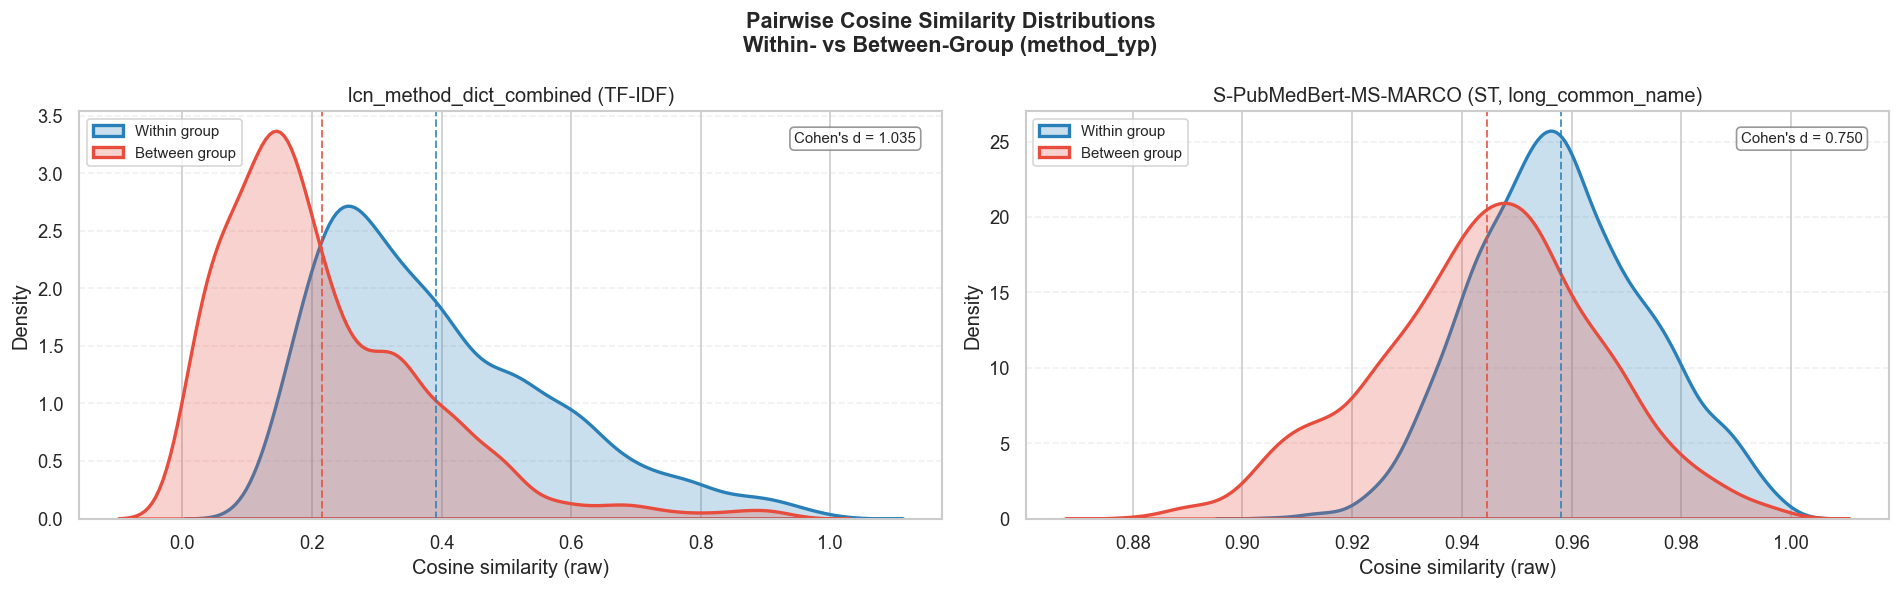

In [23]:
st_pairs = _sim_pairs_st(
    loinc,
    BEST_ST_MODEL,
    group_by="method_typ",
    input_col="long_common_name",
)
fig = plot_similarity_distributions(tfidf_pairs, st_pairs, group_by="method_typ")
fig.savefig("data/results/viz_sim_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. ELR String Diagnostics

c:\Users\prach\Desktop\LOINC codes crosswalk project\src\corpus_and_simulation_viz.py:1551: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


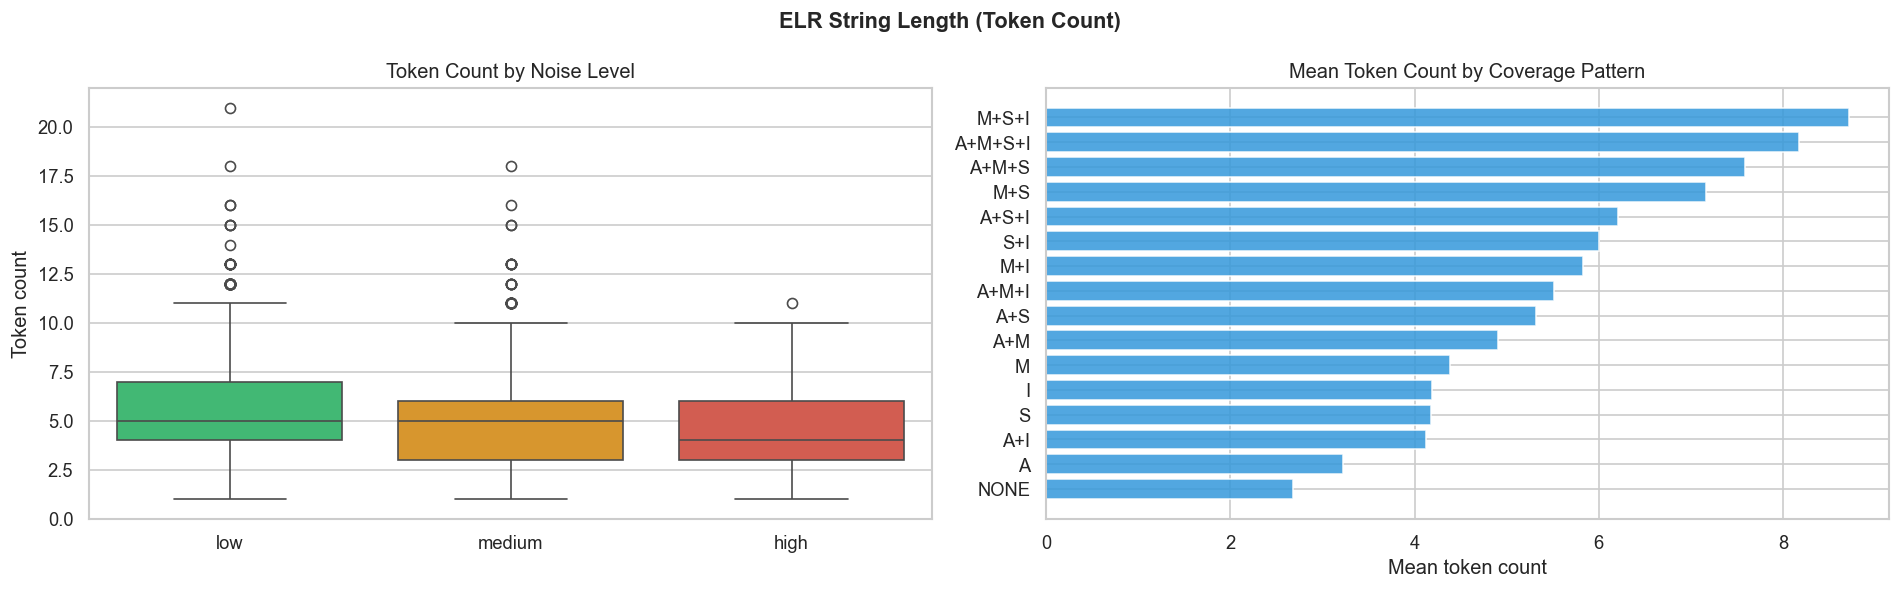

In [24]:
# Token count distribution by noise level and coverage pattern
fig = plot_elr_length_distribution(elr)
fig.savefig("data/results/viz_elr_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# Token collision audit — ELR strings that map to more than one LOINC code
print("ELR token collision audit:")
plot_elr_token_collision_audit(elr)

ELR token collision audit:
Total ELR strings:          6,600
Unique ELR strings:         5,716
Ambiguous (>1 LOINC code):  203
Collision rate:             3.55%

Top 5 ambiguous strings:
  'SARS-COV-2' -> 16 codes: ['94500-6', '94534-5', '94759-8', '94640-0', '94533-7', '94757-2', '94559-2', '94565-9', '94756-4', '95608-6', '94845-5', '95406-5', '97097-0', '96448-6', '94758-0', '94760-6']
  'SARS-COV-2 - NAAT' -> 9 codes: ['94500-6', '94534-5', '94845-5', '94757-2', '94533-7', '94559-2', '94759-8', '95608-6', '95409-9']
  'SARS-COV-2 | PCR' -> 9 codes: ['94534-5', '94756-4', '94500-6', '94640-0', '94559-2', '94533-7', '96123-5', '94758-0', '95406-5']
  'SARS-COV-2 - QPCR' -> 8 codes: ['94500-6', '94534-5', '94559-2', '95406-5', '94759-8', '94758-0', '95409-9', '94760-6']
  'SARS-COV-2 PCR' -> 8 codes: ['94500-6', '94845-5', '94534-5', '94640-0', '94559-2', '94756-4', '94533-7', '96123-5']


In [26]:
# Seed diversity check — unique ELR strings per LOINC code
elr_diversity = (
    elr.groupby("loinc_num")
    .agg(
        n_variants=("elr_name", "count"),
        n_unique_strings=("elr_name", "nunique"),
    )
    .sort_values("n_unique_strings", ascending=False)
)
print("ELR string diversity per LOINC code:")
display(elr_diversity)

ELR string diversity per LOINC code:


,n_variants,n_unique_strings
loinc_num,,
94500-6,1332,1205
94533-7,1044,942
94559-2,468,421
94756-4,300,277
94534-5,276,255
92142-9,276,249
92141-1,264,237
97097-0,240,235
95209-3,156,154
